**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

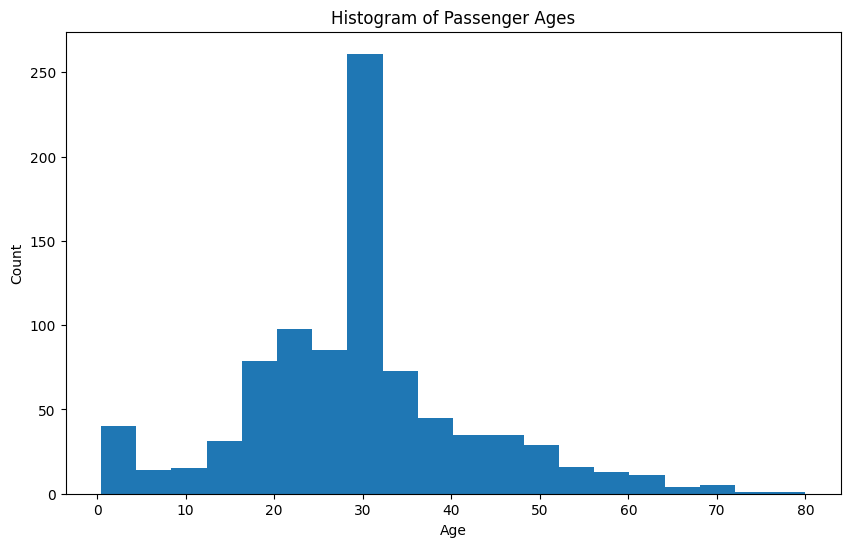

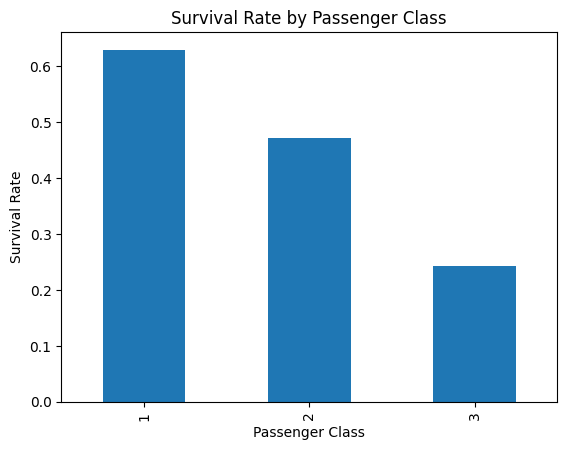

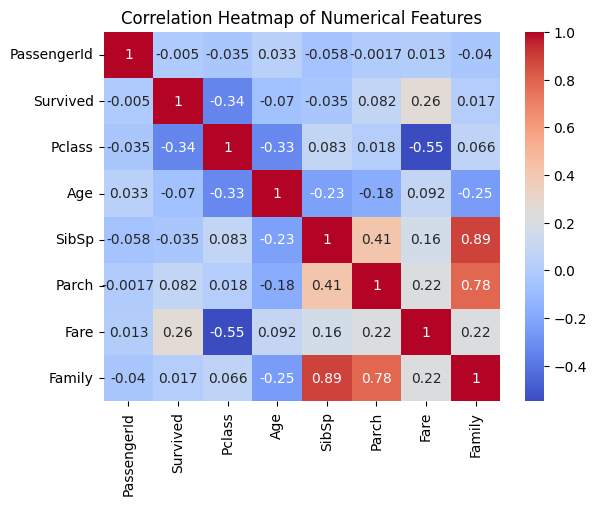

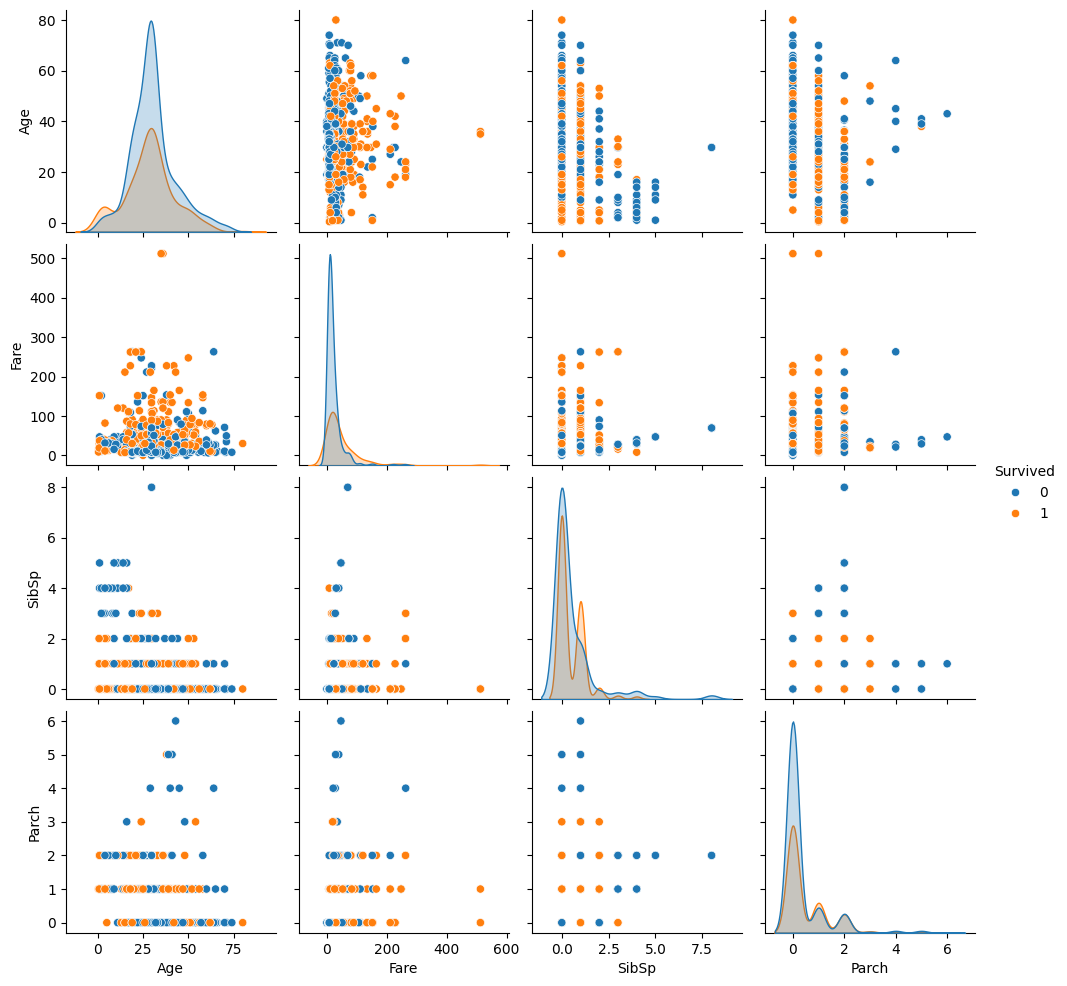

Survival Rate by Sex
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


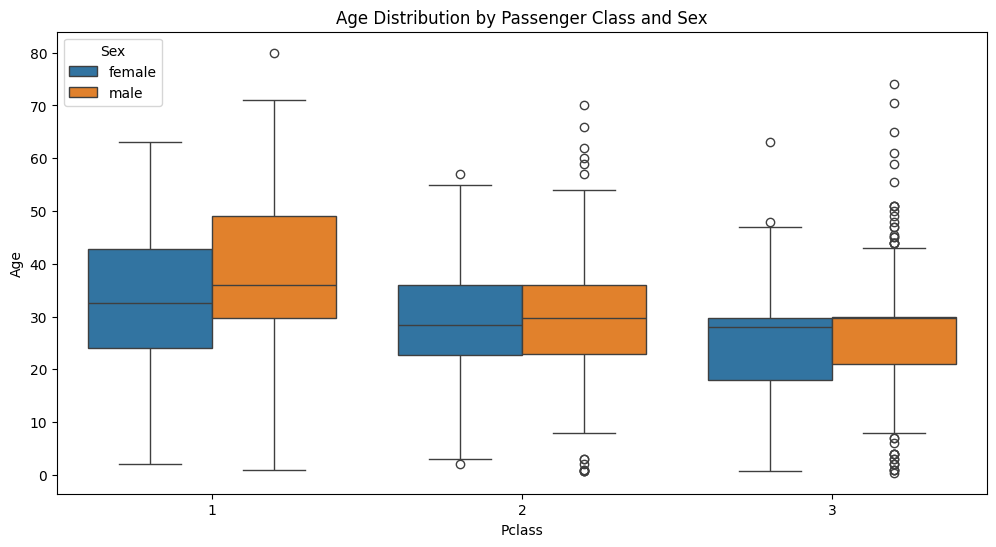

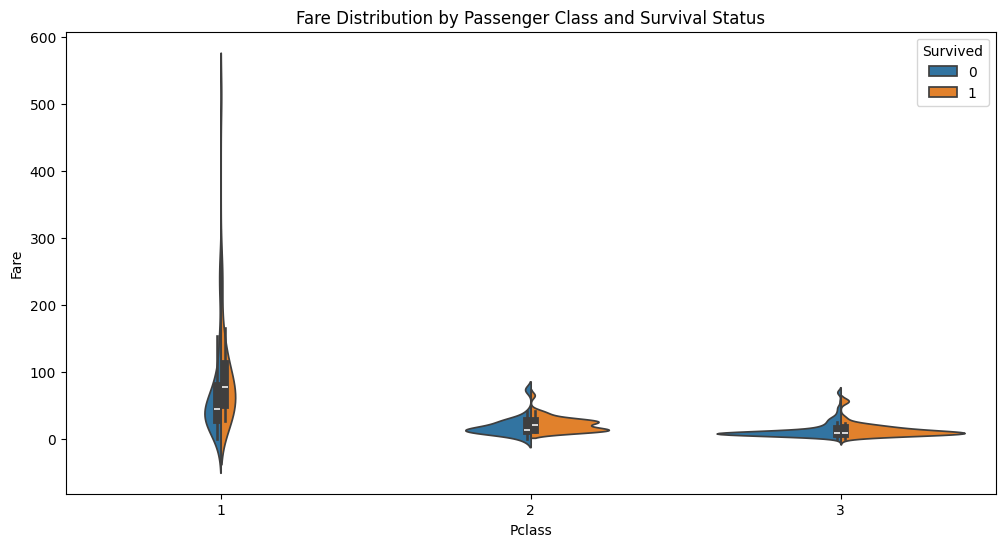

EDA tasks completed.


In [2]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
# df = ...
df = pd.read_csv("Titanic-Dataset (1).csv")

print(df.head())
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print(df.head())

# TODO: Display the last 5 rows of the dataset
print(df.tail())

# TODO: Display the data types of each column
print(df.dtypes)

# TODO: Display summary statistics of the numerical columns
print(df.describe())

# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
# df['PclassCategory'] = ...
df['PclassCategory'] = df['Pclass'].map({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
# df['CabinCategory'] = ...
df['CabinCategory'] = df['Cabin'].fillna('Unknown')
df['CabinCategory'] = df['CabinCategory'].apply(
    lambda x: 'Known' if x != 'Unknown' else 'Unknown'
)
# TODO: Handle missing values in the 'Age' column (use mean age)
# ...
df['Age'] = df['Age'].fillna(df['Age'].mean())

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
# df['Family'] = ...
df['Family'] = df['SibSp'] + df['Parch']

print(df[['PclassCategory','CabinCategory','Age','Family']].head())
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
# highest_fare_passengers = ...
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]

print("Highest Fare Passenger:")
print(highest_fare_passengers[['Name','Fare']])

# TODO: Find passengers with the largest family size
# largest_family_passengers = ...
largest_family_passengers = df[df['Family'] == df['Family'].max()]

print("\nLargest Family Size:")
print(largest_family_passengers[['Name','Family']])

# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
# names_series = ...
names_series = pd.Series(df['Name'])

print(names_series.head())

# TODO: Create a DataFrame of passenger names and ages
# names_ages_df = ...
names_ages_df = df[['Name','Age']]

print(names_ages_df.head())

# TODO: Slice the DataFrame to show only passengers older than 50
# older_passengers = ...

older_passengers = names_ages_df[names_ages_df['Age'] > 50]

print(older_passengers.head())

# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
# multi_index_df = ...
multi_index_df = df.groupby(
    ['Sex','Pclass']
)['Survived'].mean()

print(multi_index_df)

# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
# plt.figure(figsize=(10, 6))
# ...
# plt.title('Histogram of Passenger Ages')
# plt.xlabel('Age')
# plt.ylabel('Count')
# plt.show()

plt.figure(figsize=(10,6))

plt.hist(df['Age'], bins=20)

plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

# TODO: Create a bar plot of survival rates by passenger class
# ...
survival_by_class = df.groupby('Pclass')['Survived'].mean()

survival_by_class.plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

# TODO: Create a heatmap of correlation between numerical features
# plt.figure(figsize=(12, 10))
# ...
# plt.title('Correlation Heatmap of Numerical Features')
# plt.show()
sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
# ...
sns.pairplot(
    df[['Age','Fare','SibSp','Parch','Survived']],
    hue='Survived'
)

plt.show()

# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
# survival_by_sex = ...

# TODO: Calculate and display survival rates by passenger class
# survival_by_class = ...
survival_by_sex = df.groupby('Sex')['Survived'].mean()

print("Survival Rate by Sex")
print(survival_by_sex)

survival_by_class = df.groupby('Pclass')['Survived'].mean()

print("\nSurvival Rate by Passenger Class")
print(survival_by_class)

# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Age Distribution by Passenger Class and Sex')
# plt.show()

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Pclass',
    y='Age',
    hue='Sex',
    data=df
)

plt.title('Age Distribution by Passenger Class and Sex')

plt.show()

# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Fare Distribution by Passenger Class and Survival Status')
# plt.show()

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Pclass',
    y='Fare',
    hue='Survived',
    data=df,
    split=True
)

plt.title('Fare Distribution by Passenger Class and Survival Status')

plt.show()

print("EDA tasks completed.")

# Titanic EDA Insights

## Findings

1. Female passengers had a much higher survival rate (74.2%) than male passengers (18.9%).

2. First-class passengers had the highest survival rate (62.9%), while third-class passengers had the lowest (24.2%).

3. Most passengers were between 20 and 40 years old.

4. Passenger class was strongly related to fare price, with first-class passengers paying significantly higher fares.

5. Family size may have influenced survival outcomes for some passengers.

6. Missing values in the Age column were successfully handled using the mean age.

7. Correlation analysis showed that Fare and Pclass were moderately related, while SibSp and Parch showed a strong positive relationship.